In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
image_size = (64,64)

data_generator = ImageDataGenerator(rescale = 1/255, validation_split=0.2,
                                   width_shift_range = 0.1,    #horizontal_shift(-10% to +10%)
                                   height_shift_range = 0.1,    #vertical_shift(-10% to +10%)
                                   zoom_range = 0.15,     # zoomout(85%) to zoom in (115%)
                                    horizontal_flip = True,
                                    vertical_flip = False ,
                                    shear_range = 0.1   # -10% to +10%  tilt)
                                   )
                                    
train_generator = data_generator.flow_from_directory('face-mask-detection/', target_size=image_size,
                                                     batch_size=32,  subset = 'training')

val_generator = data_generator.flow_from_directory("face-mask-detection/", target_size = image_size,
                                                    batch_size = 32, subset = "validation")

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [3]:
train_generator.class_indices.keys()

dict_keys(['with_mask', 'without_mask'])

### Model Building

In [9]:
model = Sequential()
model.add(Conv2D(filters = 16,
         kernel_size = (3,3),
         activation = 'relu',
         input_shape = image_size + (3,)))

model.add(MaxPool2D(pool_size = (2, 2)))

model.add(Conv2D(filters = 32,
         kernel_size = (3,3),
         activation = 'relu'))

model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units = 64, activation = 'relu'))

model.add(Dense(units = 2, activation = 'sigmoid'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,690 (1.55 MB)

 Trainable params: 406,690 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = EarlyStopping(monitor = 'accuracy', patience = 5, verbose = 1)
model.compile(optimizer='adam', loss = 'binary_crossentropy',metrics = ['accuracy'])
history = model.fit(train_generator, validation_data=val_generator, callbacks = early_stopping, epochs = 30, verbose = 2)

Epoch 1/30
189/189 - 252s - 1s/step - accuracy: 0.8092 - loss: 0.4232 - val_accuracy: 0.8980 - val_loss: 0.2799
Epoch 2/30
189/189 - 53s - 279ms/step - accuracy: 0.8718 - loss: 0.3194 - val_accuracy: 0.8907 - val_loss: 0.2785
Epoch 3/30
189/189 - 82s - 432ms/step - accuracy: 0.8835 - loss: 0.2905 - val_accuracy: 0.9106 - val_loss: 0.2367
Epoch 4/30
189/189 - 44s - 235ms/step - accuracy: 0.8858 - loss: 0.2807 - val_accuracy: 0.9119 - val_loss: 0.2299
Epoch 5/30
189/189 - 98s - 518ms/step - accuracy: 0.8981 - loss: 0.2503 - val_accuracy: 0.8868 - val_loss: 0.2842
Epoch 6/30
189/189 - 59s - 314ms/step - accuracy: 0.9052 - loss: 0.2311 - val_accuracy: 0.9265 - val_loss: 0.1951
Epoch 7/30
189/189 - 48s - 256ms/step - accuracy: 0.9092 - loss: 0.2214 - val_accuracy: 0.9377 - val_loss: 0.1805
Epoch 8/30
189/189 - 48s - 252ms/step - accuracy: 0.9161 - loss: 0.2068 - val_accuracy: 0.9417 - val_loss: 0.1618
Epoch 9/30
189/189 - 43s - 227ms/step - accuracy: 0.9262 - loss: 0.1866 - val_accuracy: 0.

### Model Testing

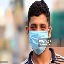

In [12]:
face_img = image.load_img("face_mask_img_2.jpg", target_size = image_size)
face_img

In [13]:
image_array = image.img_to_array(face_img)/255  #rescale pixel value 0 to 1
image_array

array([[[0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        ...,
        [0.8666667 , 0.8156863 , 0.7490196 ],
        [0.8666667 , 0.81960785, 0.77254903],
        [0.8666667 , 0.81960785, 0.77254903]],

       [[0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        ...,
        [0.8666667 , 0.8       , 0.72156864],
        [0.8627451 , 0.7882353 , 0.72156864],
        [0.8627451 , 0.7882353 , 0.72156864]],

       [[0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        [0.9137255 , 0.9529412 , 1.        ],
        ...,
        [0.87058824, 0.78431374, 0.7019608 ],
        [0.8745098 , 0.7764706 , 0.6901961 ],
        [0.8745098 , 0.7764706 , 0.6901961 ]],

       ...,

       [[0.60784316, 0.56078434, 0.5058824 ],
        [0.6117647 , 0.58431375, 0.54509807],
        [0.5921569 , 0

In [14]:
image_array.shape

(64, 64, 3)

In [15]:
test_array = image_array.reshape(1, 64, 64, 3)
test_array.shape

(1, 64, 64, 3)

In [16]:
list(model.predict(test_array)[0])
sorted(list(zip(list(train_generator.class_indices.keys()), list(model.predict(test_array)[0]))), key = lambda x:x[1])[-1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


('with_mask', np.float32(0.99999976))

In [18]:
len(list(train_generator.class_indices.keys())[1:])

1

In [20]:
def get_prediction(image_path):
    input_image = image.load_img(image_path, target_size = image_size)
    image_array = image.img_to_array(input_image)/255  
    test_array = image_array.reshape(1, 64, 64, 3)
    prediction = model.predict(test_array)
    output = sorted(list(zip(list(train_generator.class_indices.keys()), list(prediction[0]))), key = lambda x:x[1])[-1]

    return output

In [21]:
get_prediction("face_mask_img_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


('with_mask', np.float32(0.99999976))

In [22]:
get_prediction("Panda.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


('without_mask', np.float32(0.587268))

In [24]:
get_prediction("Monkey.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


('without_mask', np.float32(0.6506803))

In [25]:
model.save('lib/face_mask_detection.keras')

In [ ]:
model = 